# Fourier transforms and Fast Fourier Transform (FFT)

## Understanding the mathematics of Fourier Transform

The Fourier Transforms is a mathematical technique that transforms a time-domain signal into its frequency-domain representation. This is particurlarly useful for analyzing frequency content of signals, especially in fiels such as signal processing, physics, and engineering.

The Fourier transform of a continous function $f(t)$ is defined as:

$$F(\omega)=\int_{-\infty}^{+\infty}f(t)e^{-j\omega t}dt$$

Here:

- $t$ represents time.
- $\omega$ represents angular frequency, where $\omega=2\pi f$, and $f$ is the frequency in Hz.
- $j$ is the imaginary unit, where $j^2=-1$.
- $F(\omega)$ represents the Fourier Transform of $f(t)$

In simple terms, the Fourier Transform converts a time-domain signal into a sum of sinusoids of different frequencies. Each sinusoid has a corresponding amplitude and phase, which together describe how much of that particular frequency is present in the original signal.

## Implementing Fourier Transforms with NumPy

In Python, we can use the NumPy library to perform Fourier Transforms on discrete signals (i.e., sampled data). The `numpy.fft` provides functions to compute the Discrete Fourier Tranform (DFT) and its inverse.

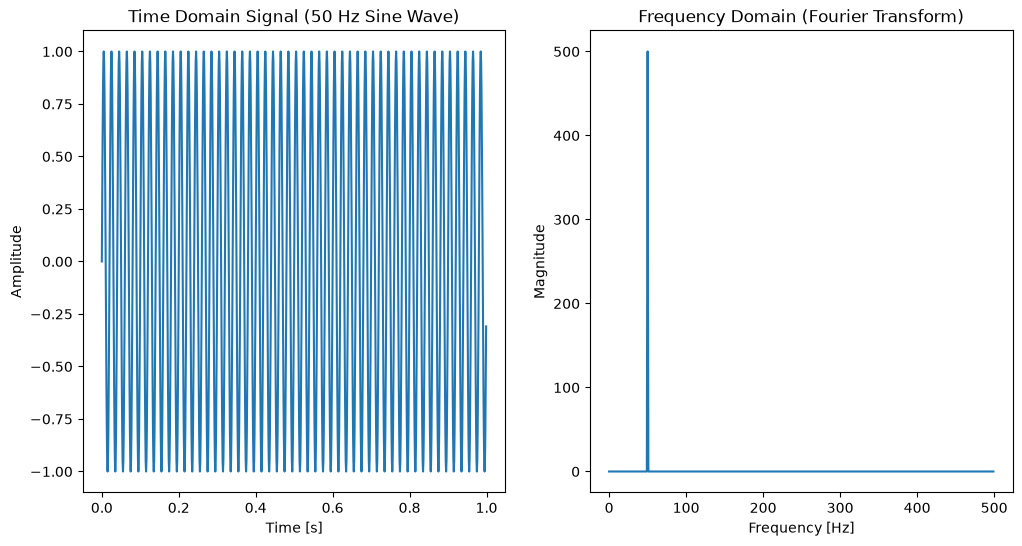

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling parameters
sampling_rate = 1000 # Samples per second
T = 1.0 / sampling_rate # Sampling period
L = 1000 # Length of signal
t = np.linspace(0, L*T, L, endpoint = False) # Time vector

# Define a sine wave signal with frequency 50 Hz
frequency = 50
amplitude = np.sin(2 * np.pi * frequency * t)

# Compute the Fourier Transform using numpy.fft.fft
fft_result = np.fft.fft(amplitude)

# Compute the corresponding frequencies
frequencies = np.fft.fftfreq(L, T)

# Plot the original signal and its Fourier Transform
plt.figure(figsize=(12, 6))

# Original signal plot
plt.subplot(1, 2, 1)
plt.plot(t, amplitude)
plt.title('Time Domain Signal (50 Hz Sine Wave)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

# Fourier Transform plot (only positive frequencies)
plt.subplot(1, 2, 2)
plt.plot(frequencies[:L//2], np.abs(fft_result)[:L//2])
plt.title('Frequency Domain (Fourier Transform)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')

plt.show()

In this example:

- We generate a sine wave with a frequency of 50 Hz.
- The `numpy.fft.fft` function computes the Fourier Transform of the signal.
- The result is a complex-valued array where the magnitude gives the amplitude of each frequency component in the signal.
- The `numpy.fft.fftfreq` function returns the corresponding frequencies for each element in the Fourier Transform result.

## Using FFT for Signal Processing

The Fast Fourier Transform (FFT) is an algorithm that efficiently computes the Discrete Fourier Transform (DFT). The FFT significantly reduces the computation time compared to the direct calculation of the DFT, making it ideal for real-time signal processing tasks.

One common application of the FFT in signal processing is to filter out noise form a signal. Consider the following example where we generate a noisy signal and use the FFT to remove the high-frequency noise:

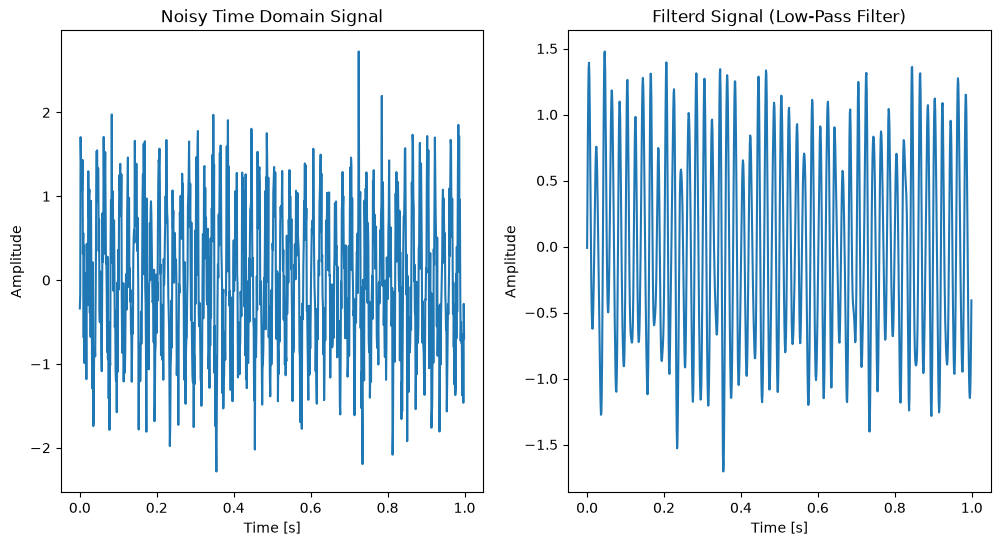

In [5]:
# Generate a noisy signal: 50 Hz sine wave + high-frequency noise
noise = 0.5 * np.random.randn(L) # Random noise
noisy_signal = amplitude + noise # Add noise to the sine wave

# Compute the FFT of the noisy signal
noisy_fft = np.fft.fft(noisy_signal)

# Apply a low-pass filter: Set high-frequency components to zero
cutoff_frequency = 100 # Frequency in Hz
noisy_fft[np.abs(frequencies) > cutoff_frequency] = 0

# Compute the inverse FFT to get the filtered signal back in time domain
filterd_signal = np.fft.ifft(noisy_fft)

# Plot the noisy signal and the filtered signal
plt.figure(figsize=(12, 6))

# Noisy signal plot
plt.subplot(1, 2, 1)
plt.plot(t, noisy_signal)
plt.title('Noisy Time Domain Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

# Filtered signal plot
plt.subplot(1, 2, 2)
plt.plot(t, filterd_signal.real)
plt.title('Filterd Signal (Low-Pass Filter)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.show()

In this example:

- We generate a noisy signal by adding random nose to a 50 Hz sine wave.
- After computing the FFT, we apply a low-pass filter by setting the Fourier coefficients of frequencies higher than the cutoff frequency to zero.
- We use the inverse FFT (`np.fft.ifft`) to convert the filtered signal back into the time domain.